In [7]:
import pandas as pd
import numpy as np
from datetime import timedelta

# Set random seed
np.random.seed(42)

# Define dataset dimensions
n_units = 30
days = 21
intervals_per_day = int((24 * 60) / 5)
total_intervals = days * intervals_per_day
fleet_ids = [f"Rover_{str(i).zfill(2)}" for i in range(1, n_units + 1)]
start_date = pd.Timestamp('2026-07-01 00:00:00')

# Operation mode weights (remove randomly generated CHARGING)
modes = ['PATROL', 'ALERT', 'FAULT']
mode_probs = [0.75, 0.20, 0.05]

data_records = []

for unit in fleet_ids:
    timestamps = [start_date + timedelta(minutes=5 * i) for i in range(total_intervals)]

    # Force data type to object to prevent NumPy string length truncation
    mode_seq = np.random.choice(modes, size=total_intervals, p=mode_probs).astype('object')

    # Initialize base physical states
    motor_current = np.zeros(total_intervals)
    battery_soc = np.zeros(total_intervals)
    battery_soc[0] = 100.0

    imu_x = np.random.normal(0, 0.1, total_intervals)
    imu_y = np.random.normal(0, 0.1, total_intervals)
    imu_z = np.random.normal(9.8, 0.1, total_intervals)
    rssi = np.random.uniform(-90, -30, total_intervals)

    # Set 25m cap based on due diligence report
    proximity = np.random.uniform(0, 25.0, total_intervals)
    task_success = np.ones(total_intervals)

    # Initialize charging status flag for a single device
    is_charging = False

    for i in range(total_intervals):
        # Threshold-driven state transition evaluation
        if i > 0:
            if battery_soc[i - 1] < 15.0 and not is_charging:
                is_charging = True
            elif battery_soc[i - 1] >= 100.0 and is_charging:
                is_charging = False

        # If in charging state, force override of randomly generated mode
        if is_charging:
            mode_seq[i] = 'CHARGING'

        if mode_seq[i] == 'CHARGING':
            motor_current[i] = np.random.uniform(0, 0.5)
            if i > 0:
                battery_soc[i] = min(100.0, battery_soc[i - 1] + np.random.uniform(2.0, 5.0))
            task_success[i] = 1

        elif mode_seq[i] == 'FAULT':
            motor_current[i] = np.random.uniform(15.0, 30.0)
            if i > 0:
                battery_soc[i] = max(0.0, battery_soc[i - 1] - np.random.uniform(0.5, 3.0))
            task_success[i] = 0
            imu_x[i] += np.random.normal(2.0, 1.0)

        else:  # PATROL or ALERT
            motor_current[i] = np.random.uniform(2.0, 10.0)
            if i > 0:
                battery_soc[i] = max(0.0, battery_soc[i - 1] - np.random.uniform(0.05, 0.2))

            if mode_seq[i] == 'ALERT':
                motor_current[i] *= 1.5
                task_success[i] = np.random.choice([0, 1], p=[0.2, 0.8])

    df_unit = pd.DataFrame({
        'unit_id': unit,
        'timestamp': timestamps,
        'motor_current': motor_current,
        'battery_soc': battery_soc,
        'imu_x': imu_x,
        'imu_y': imu_y,
        'imu_z': imu_z,
        'rssi': rssi,
        'proximity': proximity,
        'operational_mode': mode_seq,
        'task_success_flag': task_success
    })
    data_records.append(df_unit)

df_fleet = pd.concat(data_records, ignore_index=True)

# Inject random missing values for MCAR/MAR analysis
missing_mask = np.random.rand(*df_fleet[['rssi', 'proximity']].shape) < 0.05
df_fleet.loc[missing_mask[:, 0], 'rssi'] = np.nan
df_fleet.loc[missing_mask[:, 1], 'proximity'] = np.nan

df_fleet.to_csv('synthetic_sensor_dataset.csv', index=False)
print(1)

1


                 timestamp  motor_current    battery_soc          imu_x  \
count               181440  181440.000000  181440.000000  181440.000000   
mean   2026-07-11 11:57:30       7.038284      57.991958       0.094288   
min    2026-07-01 00:00:00       0.000004      12.098341      -1.928592   
25%    2026-07-06 05:58:45       4.019715      36.719165      -0.063602   
50%    2026-07-11 11:57:30       6.423809      58.105002       0.006299   
75%    2026-07-16 17:56:15       8.813542      79.305513       0.079262   
max    2026-07-21 23:55:00      29.998036     100.000000       5.765906   
std                    NaN       4.734412      24.675303       0.485634   

               imu_y          imu_z           rssi      proximity  \
count  181440.000000  181440.000000  172242.000000  172291.000000   
mean       -0.000661       9.800197     -59.956325      12.505761   
min        -0.464442       9.371095     -89.999977       0.000056   
25%        -0.068125       9.732711     -74.9116

<Figure size 1000x400 with 0 Axes>

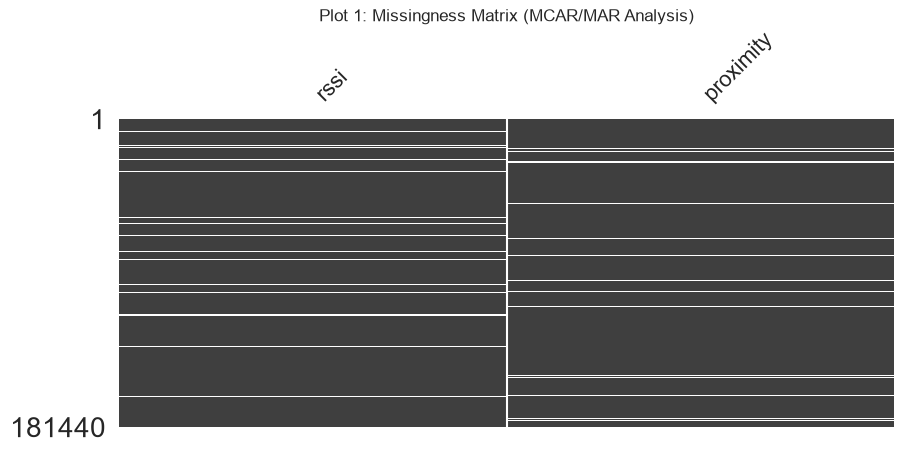

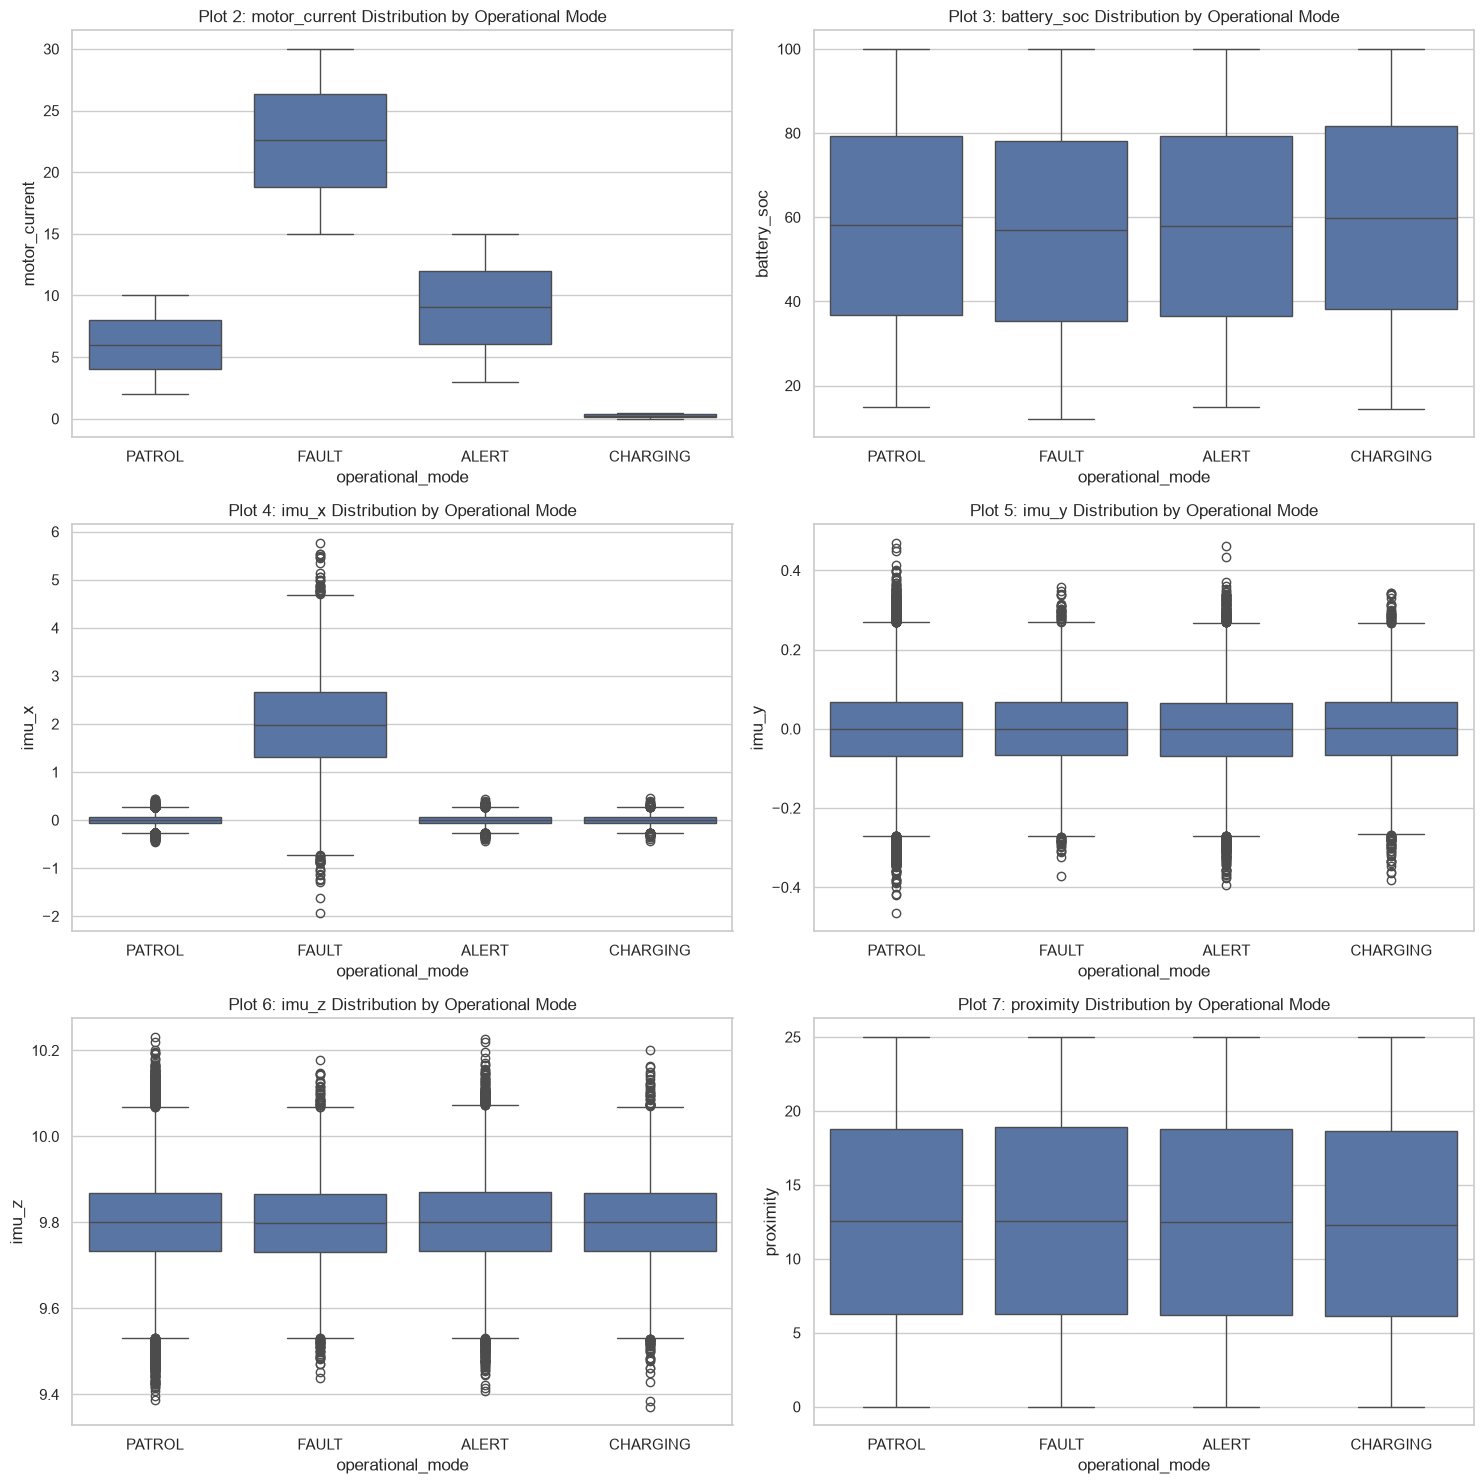

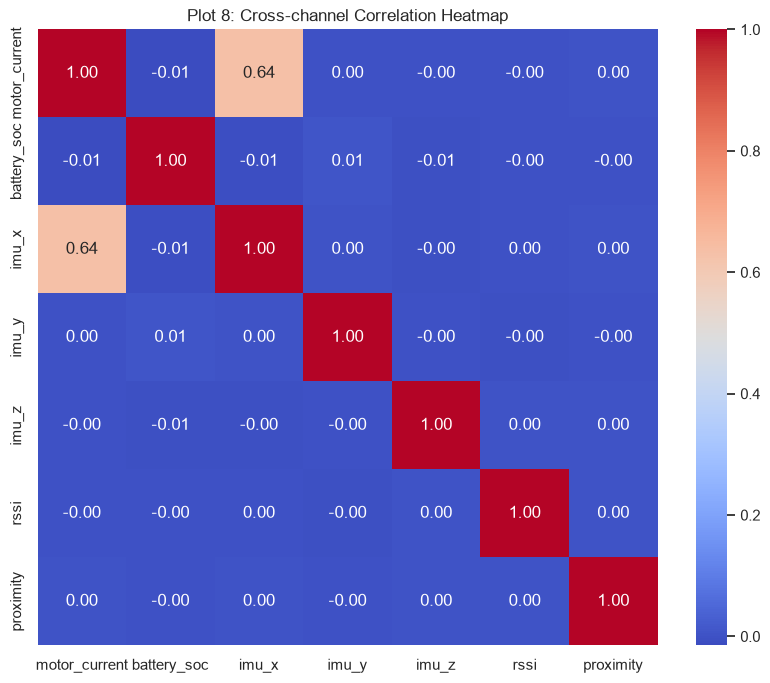

--- ADF Test for Motor Current ---
ADF Statistic: -14.0304
p-value: 0.0000
--- ADF Test for Battery SoC ---
ADF Statistic: -7.6223
p-value: 0.0000


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from statsmodels.tsa.stattools import adfuller


print(df_fleet.describe())

# Missing value analysis (MCAR/MAR hypothesis testing)
fig_missing = plt.figure(figsize=(10, 4))
msno.matrix(df_fleet[['rssi', 'proximity']], sparkline=False, figsize=(10,4))
plt.title("Plot 1: Missingness Matrix (MCAR/MAR Analysis)", fontsize=12)
plt.show()

# setting style
sns.set_theme(style="whitegrid")
num_cols = ['motor_current', 'battery_soc', 'imu_x', 'imu_y', 'imu_z', 'proximity']

# Distribution plot generation (Plot 2-7)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_fleet, x='operational_mode', y=col, ax=axes[i])
    axes[i].set_title(f"Plot {i+2}: {col} Distribution by Operational Mode")

plt.tight_layout()
plt.show()

# Distribution plot generation (Plot 8)
plt.figure(figsize=(10, 8))
corr_matrix = df_fleet[['motor_current', 'battery_soc', 'imu_x', 'imu_y', 'imu_z', 'rssi', 'proximity']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Plot 8: Cross-channel Correlation Heatmap")
plt.show()

# Stationarity test (ADF Test)
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

sample_unit = df_fleet[df_fleet['unit_id'] == 'Rover_01']
run_adf_test(sample_unit['motor_current'], "Motor Current")
run_adf_test(sample_unit['battery_soc'], "Battery SoC")